In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv("financial_data.csv")
df = df.dropna(subset=["Görüs Tipi"])
df["risk"] = df["Görüs Tipi"].map({
    "Olumlu":0,
    "Şartlı":1,
    "Olumsuz":1,
    "Görüş bildirmekten kaçınma":1
})
cols_to_drop = ['Şirket Adı', 'Şirketin Kodu',"Görüs Tipi"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
df['Periyot'] = df['Periyot'].astype(str).str.replace(r'(?i)yıllık', '12', regex=True)
df['Periyot'] = (df['Periyot'].str.extract(r'^\s*(\d+)', expand=False).astype(float))
df['Periyot'] = df['Periyot'].astype('Int64')
y=df["risk"]
X = df.drop(columns=["risk"])

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [4]:
scaler = StandardScaler()

In [5]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [7]:
scale_weight

8.419496166484118

In [8]:
xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state = 42,
    eval_metric='logloss'
)

In [9]:
xgb.fit(X_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
y_pred = xgb.predict(X_test_scaled)

Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1923
           1       0.62      0.51      0.56       228

    accuracy                           0.91      2151
   macro avg       0.78      0.74      0.76      2151
weighted avg       0.91      0.91      0.91      2151



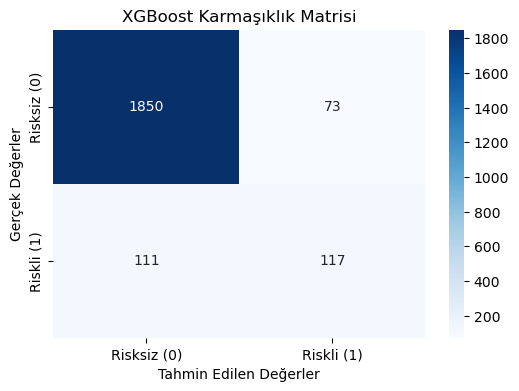

In [11]:
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Risksiz (0)', 'Riskli (1)'], 
            yticklabels=['Risksiz (0)', 'Riskli (1)'])
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.title('XGBoost Karmaşıklık Matrisi')
plt.show()

In [12]:
y_pred_proba = xgb.predict_proba(X_test_scaled)[:, 1]

custom_threshold = 0.30
y_pred_lower_threshold = (y_pred_proba >= custom_threshold).astype(int)

print(f"Eşik Değeri {custom_threshold} İçin Yeni Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_lower_threshold))

Eşik Değeri 0.3 İçin Yeni Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1923
           1       0.53      0.58      0.56       228

    accuracy                           0.90      2151
   macro avg       0.74      0.76      0.75      2151
weighted avg       0.91      0.90      0.90      2151



In [13]:
import shap

In [14]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [15]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled_df)

En Önemli Finansal Göstergeler (Genel Bakış):


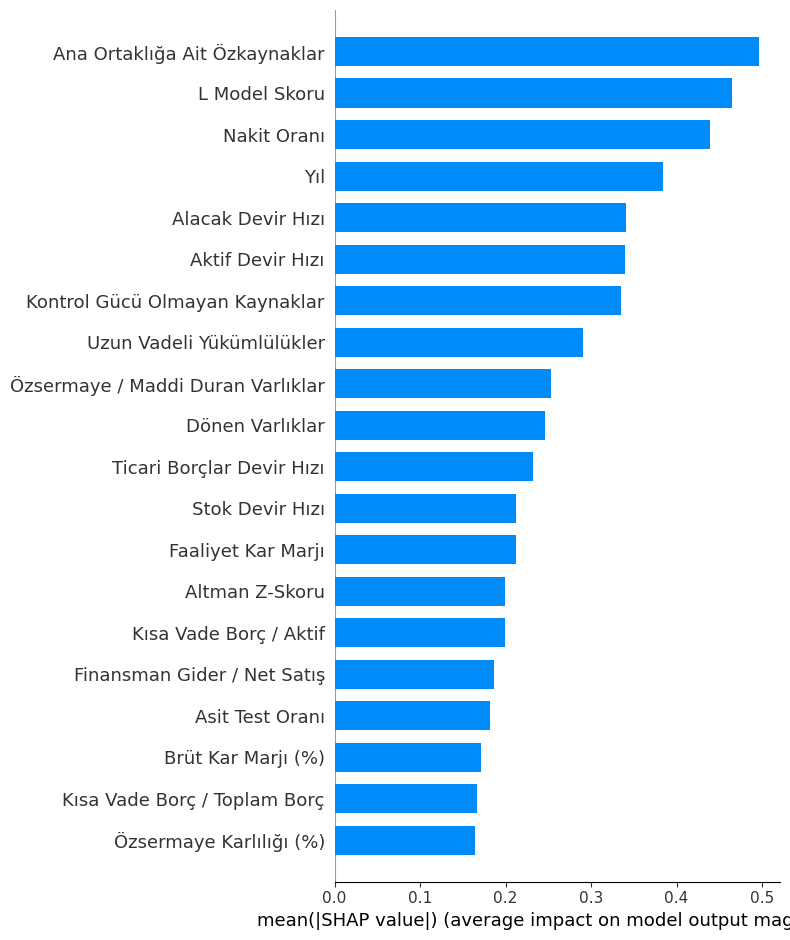

In [16]:
plt.rcParams.update({'figure.figsize':(10,6)})
print("En Önemli Finansal Göstergeler (Genel Bakış):")
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar", show=False)
plt.show()


Finansal Göstergelerin Riski Tetikleme Yönü:


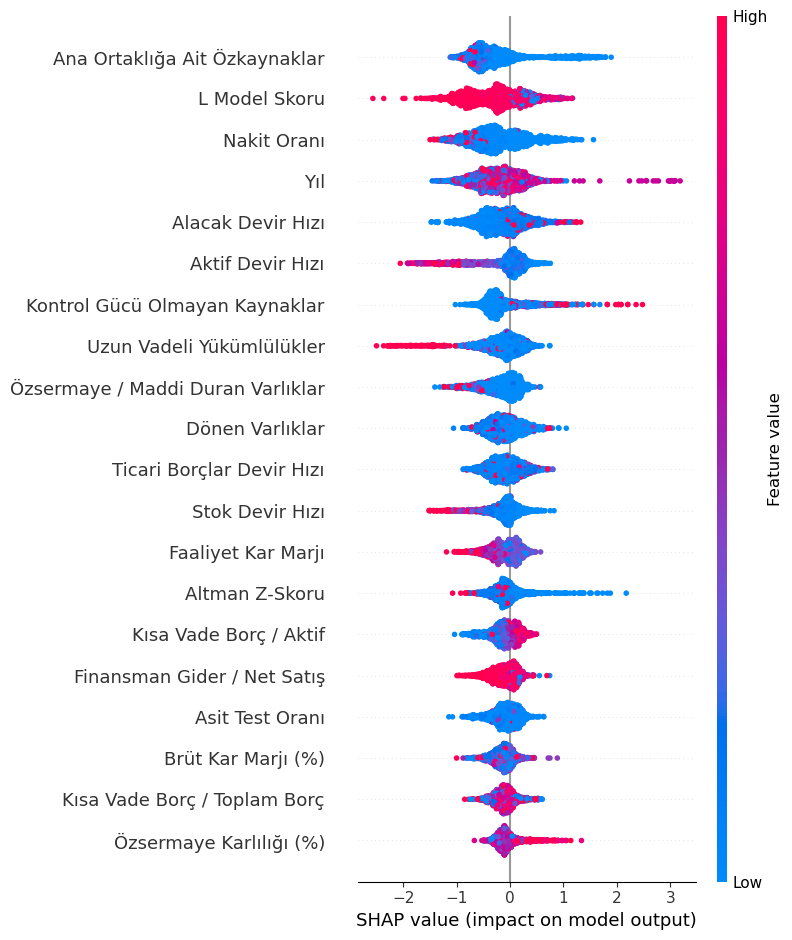

In [17]:
print("\nFinansal Göstergelerin Riski Tetikleme Yönü:")
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.show()

# Optimized Model

In [19]:
feature_importance = xgb.feature_importances_
importance_df = pd.DataFrame({"Feature":X.columns,"Importance":feature_importance})
importance_df=importance_df.sort_values(by="Importance",ascending=False)

In [21]:
top_20 = importance_df["Feature"].head(20).tolist()

In [24]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_selected = X_train_df[top_20].values
X_test_selected = X_test_df[top_20].values

In [25]:
#hyperparameter tuning

In [26]:
params={
    'max_depth':[3, 4, 5, 6, 8],
    'learning_rate':[0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [27]:
xgb_tune = XGBClassifier(scale_pos_weight=scale_weight,random_state=42)

In [30]:
random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=params,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

In [31]:
random_search.fit(X_train_selected, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1')

In [32]:
best_xgb_model = random_search.best_estimator_
print(f"Bulunan En İyi Parametreler: {random_search.best_params_}\n")

Bulunan En İyi Parametreler: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}



In [34]:
y_pred_proba = best_xgb_model.predict_proba(X_test_selected)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

In [39]:
f2_scores = []
for p, r in zip(precisions[:-1], recalls[:-1]):
    if p + r == 0:
        f2_scores.append(0)
    else:
        f2 = (5 * p * r) / ((4 * p) + r) # F2 Formülü
        f2_scores.append(f2)

In [40]:
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Matematiksel Olarak Hesaplanmış En İyi Eşik Değeri: {optimal_threshold:.4f}\n")

y_pred_final = (y_pred_proba >= optimal_threshold).astype(int)

print("--- OPTİMİZE EDİLMİŞ FİNAL MODEL SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred_final))

--- 3. ADIM: EŞİK DEĞERİ SEÇİMİ ---
Matematiksel Olarak Hesaplanmış En İyi Eşik Değeri: 0.3436

--- OPTİMİZE EDİLMİŞ FİNAL MODEL SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1923
           1       0.39      0.81      0.53       228

    accuracy                           0.85      2151
   macro avg       0.68      0.83      0.72      2151
weighted avg       0.91      0.85      0.87      2151

